In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import sys


In [ ]:
metrics_dict = {'SUBJECT': 'Subject'
                ,'LABEL': 'Label'
                ,'ADJRIND':
                ,'AUC':
                ,'AVGDIST':
                ,'DICE':
                ,'FN':
                ,'FP':
                ,'HDRFDST':
                ,'JACRD':
                ,'MUTINF':
                ,'PRCISON':
                ,'RNDIND':
                ,'SNSVTY':
                ,'SPCFTY':
                ,'TN':
                ,'TP':
                ,'VOLSMTY'}

In [28]:
def load_data(file_path):
    """
    Loads the CSV file into a pandas DataFrame.
    
    Parameters:
        file_path (str): Path to the CSV file.
    
    Returns:
        DataFrame: Loaded data.
    """
    try:
        data = pd.read_csv(file_path, delimiter = ';')

        return data
    except Exception as e:
        print(f"Error loading file: {e}")
        return None


In [30]:
# File path to your CSV
file_path = "mia-result/2024-11-21-21-03-54/results.csv"  # Update this to the actual path of your file

# Load and preprocess the data
data = load_data(file_path)
data.describe()
data.head(10)


,SUBJECT,LABEL,ADJRIND,AUC,AVGDIST,DICE,FN,FP,HDRFDST,JACRD,MUTINF,PRCISON,RNDIND,SNSVTY,SPCFTY,TN,TP,VOLSMTY
0,117122,Amygdala,0.448536,0.923676,2.340080,0.449141,457.0,5798.0,38.444766,0.289608,0.002805,0.305462,0.998559,0.848021,0.999331,8666484.0,2550.0,0.529635
1,117122,GreyMatter,0.632965,0.931617,0.402112,0.693388,46998.0,359619.0,20.248457,0.530677,0.179891,0.561115,0.910652,0.907260,0.955975,7808899.0,459773.0,0.764267
2,117122,Hippocampus,0.482819,0.958481,1.842281,0.484528,704.0,16254.0,36.138622,0.319721,0.007635,0.329013,0.996098,0.918838,0.998125,8650361.0,7970.0,0.527327
3,117122,Thalamus,0.666718,0.922252,2.434527,0.668629,2649.0,11760.0,72.242647,0.502211,0.013632,0.552801,0.996684,0.845863,0.998642,8646343.0,14537.0,0.790470
4,117122,WhiteMatter,0.717051,0.966363,0.464539,0.762276,16326.0,270399.0,17.916473,0.615869,0.207200,0.629641,0.936083,0.965704,0.967022,7928863.0,459701.0,0.789348
5,117122-PP,Amygdala,0.448536,0.923676,2.340080,0.449141,457.0,5798.0,38.444766,0.289608,0.002805,0.305462,0.998559,0.848021,0.999331,8666484.0,2550.0,0.529635
6,117122-PP,GreyMatter,0.632965,0.931617,0.402112,0.693388,46998.0,359619.0,20.248457,0.530677,0.179891,0.561115,0.910652,0.907260,0.955975,7808899.0,459773.0,0.764267
7,117122-PP,Hippocampus,0.482819,0.958481,1.842281,0.484528,704.0,16254.0,36.138622,0.319721,0.007635,0.329013,0.996098,0.918838,0.998125,8650361.0,7970.0,0.527327
8,117122-PP,Thalamus,0.666718,0.922252,2.434527,0.668629,2649.0,11760.0,72.242647,0.502211,0.013632,0.552801,0.996684,0.845863,0.998642,8646343.0,14537.0,0.790470
9,117122-PP,WhiteMatter,0.717051,0.966363,0.464539,0.762276,16326.0,270399.0,17.916473,0.615869,0.207200,0.629641,0.936083,0.965704,0.967022,7928863.0,459701.0,0.789348


In [42]:
def plot_metric_distributions(data, metrics, bins=50, figsize=(15, 10)):
    """
    Plots the distributions of specified metrics from the DataFrame.
    
    Parameters:
        data (DataFrame): Processed data containing the metrics.
        metrics (list of str): List of metrics to plot (e.g., ['TP', 'TN', 'FP', 'FN']).
        bins (int): Number of bins for histograms.
        figsize (tuple): Figure size for the plots.
    """
    num_metrics = len(metrics)
    fig, axes = plt.subplots(nrows=(num_metrics + 1) // 2, ncols=2, figsize=figsize)

    # Flatten axes for easy iteration
    axes = axes.flatten() if num_metrics > 1 else [axes]
    
    for idx, metric in enumerate(metrics):
        if metric not in data.columns:
            print(f"Metric '{metric}' not found in data. Skipping...")
            continue

        # Plot the distribution
        axes[idx].boxplot(data[metric])
        axes[idx].set_title(f"Distribution of {metric}")
        axes[idx].set_xlabel(metric)
        axes[idx].set_ylabel("Frequency")
        axes[idx].grid(True)

    # Remove any empty subplots
    for idx in range(len(metrics), len(axes)):
        axes[idx].axis("off")

    plt.tight_layout()
    plt.show()

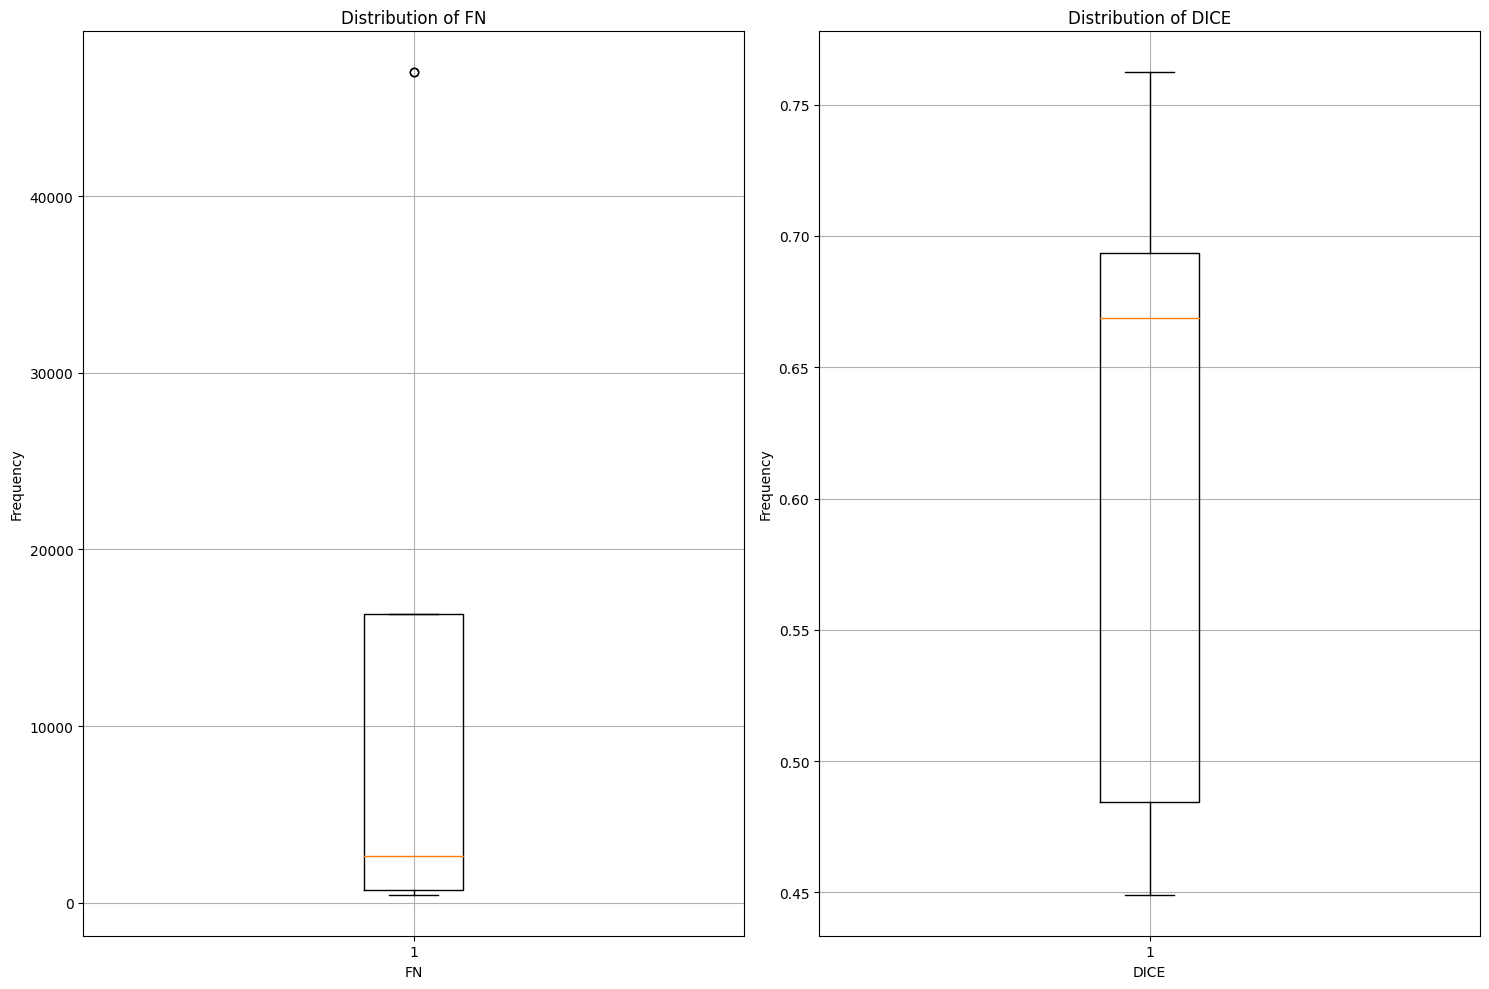

In [43]:
plot_metric_distributions(data, metrics = ['FN', 'DICE'])

In [ ]:
#todo create plotting for the non optimised models
# create plotting for the small and large structure models
# IDEA: maybe something with red and white? plot also confidence intervals? also